# Taller de Regresión Logística y Comparacion con SCV — Aprobación de Crédito

- Johel Santiago Arias Becerra
- Daniela Fierro Madrigal

**Objetivo:** entrenar un modelo de regresión logística (con escalamiento de variables) para predecir la aprobación de solicitudes de crédito, evaluar su desempeño sobre un conjunto de prueba y traducir sus coeficientes a una interpretación de negocio.

**Dataset:** `aprobacion_credito_taller.csv` — 1.000 solicitudes de crédito con las siguientes columnas:

| Columna | Descripción |
|---|---|
| `ingreso_mensual_kcop` | Ingreso mensual del solicitante, en miles de pesos colombianos (COP) |
| `score_buro` | Score de central de riesgo (buró de crédito) |
| `antiguedad_laboral_anios` | Antigüedad laboral, en años |
| `num_creditos_activos` | Número de créditos activos que tiene el solicitante |
| `dti` | Debt-to-Income: proporción de la deuda mensual sobre el ingreso mensual |
| `aprobado` | Variable objetivo: 1 si el crédito fue aprobado, 0 si no |


In [ ]:
# 1. Librerías
# Cargamos las librerías de manipulación de datos, modelado y evaluación que se usarán en todo el desarrollo.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, roc_curve, classification_report
)

pd.set_option('display.float_format', '{:.3f}'.format)


In [ ]:
# 2. Carga del dataset y exploración inicial
# Antes de modelar, revisamos la forma del dataset, los tipos de dato y si existen valores nulos.

credito = pd.read_csv('aprobacion_credito_taller.csv')

print("Dimensiones del dataset:", credito.shape)
print("\nTipos de dato:")
print(credito.dtypes)
print("\nValores nulos por columna:")
print(credito.isna().sum())

credito.describe()


Dimensiones del dataset: (1000, 6)

Tipos de dato:
ingreso_mensual_kcop        float64
score_buro                    int64
antiguedad_laboral_anios    float64
num_creditos_activos          int64
dti                         float64
aprobado                      int64
dtype: object

Valores nulos por columna:
ingreso_mensual_kcop        0
score_buro                  0
antiguedad_laboral_anios    0
num_creditos_activos        0
dti                         0
aprobado                    0
dtype: int64


,ingreso_mensual_kcop,score_buro,antiguedad_laboral_anios,num_creditos_activos,dti,aprobado
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,3994.972,649.750,12.717,1.275,0.355,0.274
std,1885.088,84.012,7.226,1.125,0.179,0.446
min,251.000,371.000,0.000,0.000,0.020,0.000
25%,2611.750,589.750,6.300,0.000,0.216,0.000
50%,3735.500,649.000,13.000,1.000,0.334,0.000
75%,5049.500,709.250,19.100,2.000,0.485,1.000
max,11350.000,850.000,25.000,6.000,0.810,1.000


### Balance de la variable objetivo

Antes de dividir los datos, revisamos qué tan balanceada está la variable `aprobado`. Si una clase es mucho más frecuente que la otra, el accuracy por sí solo puede ser engañoso, y por eso el enunciado también pide precisión, recall y AUC.

In [ ]:
# 3. Distribución de la variable objetivo

conteo = credito['aprobado'].value_counts()
proporcion = credito['aprobado'].value_counts(normalize=True)

resumen_balance = pd.DataFrame({'conteo': conteo, 'proporcion': proporcion})
resumen_balance


,conteo,proporcion
aprobado,,
0,726,0.726
1,274,0.274


In [ ]:
# 4. Definición de variables predictoras (X) y variable objetivo (y)
# Usamos las cinco variables numéricas del dataset como predictores; 'aprobado' es la variable a predecir.

X = credito[['ingreso_mensual_kcop', 'score_buro', 'antiguedad_laboral_anios',
             'num_creditos_activos', 'dti']]
y = credito['aprobado']

X.head()


,ingreso_mensual_kcop,score_buro,antiguedad_laboral_anios,num_creditos_activos,dti
0,8006.000,689,15.100,0,0.333
1,3164.000,458,13.000,2,0.512
2,3658.000,664,18.600,0,0.162
3,3108.000,608,6.400,1,0.350
4,2759.000,609,22.300,2,0.259


In [ ]:
# 5. División en conjunto de entrenamiento y de prueba (70% / 30%)
# Usamos 'stratify=y' para que la proporción de créditos aprobados/no aprobados se mantenga similar
# en ambos conjuntos, dado que la clase 'aprobado' está desbalanceada (~27% de aprobados).

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, test_size=0.3, random_state=42, stratify=y
)

print("Tamaño del conjunto de entrenamiento:", X_train.shape[0])
print("Tamaño del conjunto de prueba:", X_test.shape[0])
print("\nProporción de aprobados en entrenamiento:", round(y_train.mean(), 3))
print("Proporción de aprobados en prueba:", round(y_test.mean(), 3))


Tamaño del conjunto de entrenamiento: 700
Tamaño del conjunto de prueba: 300

Proporción de aprobados en entrenamiento: 0.274
Proporción de aprobados en prueba: 0.273


### ¿Por qué escalar las variables?

Las variables predictoras están en escalas muy distintas: `ingreso_mensual_kcop` se mueve en miles, `score_buro` en cientos, `dti` es una proporción entre 0 y 1, etc. La regresión logística es sensible a estas diferencias de escala, y además **cuando se comparan los coeficientes para identificar qué variable influye más, esa comparación solo es justa si todas las variables están en la misma escala**.

Por eso se estandariza cada variable (media 0, desviación estándar 1) usando `StandardScaler`, ajustado únicamente con los datos de entrenamiento para evitar fuga de información (*data leakage*) hacia el conjunto de prueba.

In [ ]:
# 6. Escalamiento de variables
# El escalador se ajusta ('fit') solo con el conjunto de entrenamiento, y luego se aplica ('transform')
# tanto al entrenamiento como a la prueba, para que la prueba no influya en el ajuste del escalador.

escalador = StandardScaler()
X_train_esc = escalador.fit_transform(X_train)
X_test_esc = escalador.transform(X_test)


In [ ]:
# 7. Entrenamiento de la regresión logística
# Se entrena el modelo sobre las variables ya escaladas.

modelo = LogisticRegression(random_state=42)
modelo.fit(X_train_esc, y_train)


LogisticRegression(random_state=42)

In [ ]:
# 8. Predicciones sobre el conjunto de prueba
# Se generan tanto la clase predicha (0/1, con punto de corte por defecto de 0.5) como la probabilidad
# de aprobación, necesaria para calcular el AUC.

y_pred = modelo.predict(X_test_esc)
y_proba = modelo.predict_proba(X_test_esc)[:, 1]


### Métricas de evaluación

Sobre el conjunto de prueba se calculan cuatro métricas, cada una responde una pregunta distinta:

- **Accuracy**: de todas las solicitudes, ¿qué porcentaje se clasificó correctamente?
- **Precisión**: de las solicitudes que el modelo aprobó, ¿qué porcentaje realmente debía aprobarse?
- **Recall (sensibilidad)**: de las solicitudes que realmente debían aprobarse, ¿qué porcentaje detectó el modelo?
- **AUC**: qué tan bien separa el modelo, en general, a los aprobados de los no aprobados, sin depender de un punto de corte específico.

In [ ]:
# 9. Cálculo de métricas sobre el conjunto de prueba

exactitud = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
sensibilidad = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'AUC'],
    'Valor': [exactitud, precision, sensibilidad, auc]
})
metricas


,Métrica,Valor
0,Accuracy,0.817
1,Precisión,0.729
2,Recall,0.524
3,AUC,0.869


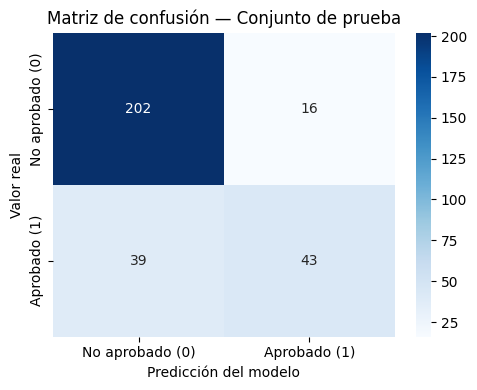

In [ ]:
# 10. Matriz de confusión
# Complementa las métricas anteriores mostrando en detalle los aciertos y errores del modelo.

matriz_confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No aprobado (0)', 'Aprobado (1)'],
            yticklabels=['No aprobado (0)', 'Aprobado (1)'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Conjunto de prueba')
plt.tight_layout()
plt.show()


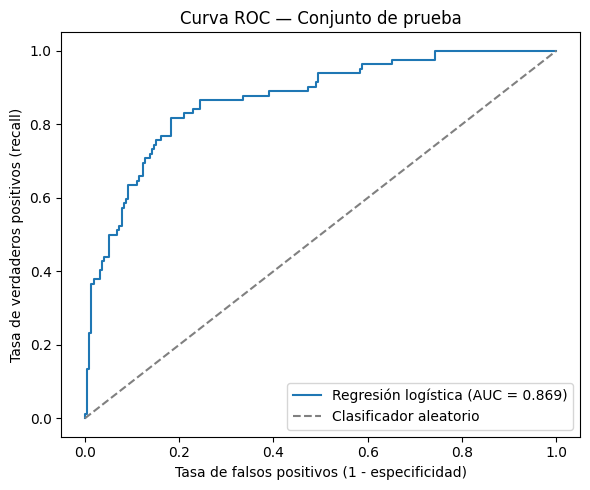

In [ ]:
# 11. Curva ROC
# Visualiza el comportamiento del modelo (sensibilidad vs. tasa de falsos positivos) para todos los
# posibles puntos de corte, y confirma visualmente el valor de AUC calculado arriba.

fpr, tpr, umbrales = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Regresión logística (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos (1 - especificidad)')
plt.ylabel('Tasa de verdaderos positivos (recall)')
plt.title('Curva ROC — Conjunto de prueba')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 12. Reporte de clasificación completo (referencia adicional)

print(classification_report(y_test, y_pred, target_names=['No aprobado (0)', 'Aprobado (1)']))


                 precision    recall  f1-score   support

No aprobado (0)       0.84      0.93      0.88       218
   Aprobado (1)       0.73      0.52      0.61        82

       accuracy                           0.82       300
      macro avg       0.78      0.73      0.75       300
   weighted avg       0.81      0.82      0.81       300



### Coeficientes y odds ratios

El modelo se entrenó sobre variables **estandarizadas** (media 0, desviación estándar 1). Esto tiene una consecuencia importante para la interpretación:

- Cada coeficiente representa el cambio en el logaritmo de las probabilidades (*log-odds*) de aprobación asociado a un aumento de **una desviación estándar** en esa variable (no una unidad "cruda" como un año o mil pesos).
- El **odds ratio** se obtiene como `exp(coeficiente)`. Un odds ratio mayor a 1 indica que la variable aumenta la probabilidad de aprobación; uno menor a 1 indica que la disminuye.
- Como todas las variables quedaron en la misma escala, el tamaño del coeficiente (o qué tan lejos está el odds ratio de 1) sí es directamente comparable entre variables — por eso se escaló antes de entrenar.

In [ ]:
# 13. Extracción de coeficientes y odds ratios

coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente (escala estandarizada)': modelo.coef_[0],
})
coeficientes['Odds Ratio'] = np.exp(coeficientes['Coeficiente (escala estandarizada)'])
coeficientes['Magnitud del efecto'] = coeficientes['Coeficiente (escala estandarizada)'].abs()

coeficientes = coeficientes.sort_values('Magnitud del efecto', ascending=False).reset_index(drop=True)
coeficientes


,Variable,Coeficiente (escala estandarizada),Odds Ratio,Magnitud del efecto
0,score_buro,1.123,3.075,1.123
1,dti,-0.757,0.469,0.757
2,num_creditos_activos,-0.534,0.586,0.534
3,antiguedad_laboral_anios,0.311,1.365,0.311
4,ingreso_mensual_kcop,-0.015,0.985,0.015


### Las 2 variables más influyentes

"Más influyente" se define aquí como el mayor valor absoluto del coeficiente estandarizado, es decir, el mayor efecto sobre el log-odds por cada desviación estándar de cambio en la variable (criterio válido porque todas las variables están en la misma escala).

In [ ]:
# 14. Identificación de las 2 variables más influyentes

top_2 = coeficientes.head(2)
top_2


,Variable,Coeficiente (escala estandarizada),Odds Ratio,Magnitud del efecto
0,score_buro,1.123,3.075,1.123
1,dti,-0.757,0.469,0.757


In [ ]:
# 15. Desviaciones estándar originales de las variables (insumo para la interpretación de negocio)
# Se calculan sobre el conjunto de entrenamiento, que es sobre el que se ajustó el escalador.

desviaciones = pd.DataFrame({
    'Variable': X.columns,
    'Media (train)': X_train.mean().values,
    'Desviación estándar (train)': X_train.std().values
})
desviaciones


,Variable,Media (train),Desviación estándar (train)
0,ingreso_mensual_kcop,4017.753,1903.048
1,score_buro,648.931,83.571
2,antiguedad_laboral_anios,12.954,7.156
3,num_creditos_activos,1.281,1.114
4,dti,0.360,0.181


### Interpretación de negocio (para el equipo comercial)

Este análisis se apoya en un modelo con un desempeño razonable sobre datos que no vio durante el entrenamiento (AUC de 0.869, accuracy de 81.7%), lo que da un respaldo razonable a las siguientes conclusiones.

**El score de buró es, con diferencia, el factor que más pesa en la decisión de aprobación.** Por cada incremento de aproximadamente 84 puntos en el score (una desviación estándar en esta base de datos), las probabilidades de que el crédito se apruebe se multiplican por cerca de 3 veces (odds ratio de 3.08), manteniendo todo lo demás igual. En otras palabras: mejorar o verificar bien el historial crediticio del solicitante es, de lejos, lo que más mueve la balanza hacia la aprobación.

**El segundo factor en importancia es el nivel de endeudamiento (DTI), y actúa en contra de la aprobación.** Por cada incremento de aproximadamente 18 puntos porcentuales en la proporción deuda/ingreso (una desviación estándar), las probabilidades de aprobación caen a menos de la mitad (odds ratio de 0.47, una reducción cercana al 53%). Esto confirma algo que el área comercial ya intuye: prestarle a alguien que ya destina gran parte de su ingreso a pagar otras deudas es más riesgoso, y el modelo lo penaliza con fuerza.

Dos hallazgos adicionales que vale la pena mencionar en el comité de crédito:

- El número de créditos activos también reduce la probabilidad de aprobación (odds ratio de 0.59, ~41% menos), aunque pesa menos que el DTI. Es, en el fondo, otra forma de medir qué tan comprometida está la capacidad de pago del solicitante.
- **El ingreso mensual, por sí solo, prácticamente no influye en la decisión** una vez que ya se tiene en cuenta el score de buró y el DTI (odds ratio de 0.99, un efecto casi nulo). Este es un hallazgo útil para el negocio: no es "cuánto gana" la persona lo que más determina la aprobación, sino qué tan sano es su historial crediticio y qué tan comprometido está ya ese ingreso con otras deudas.

**En resumen:** el modelo aprueba más fácilmente a solicitantes con buen historial en el buró y bajo nivel de endeudamiento, casi sin importar si su ingreso es alto o bajo.


## Comparación con SVC (Máquinas de Vectores de Soporte) con kernel RBF

**Objetivo de esta sección:** entrenar un SVC con kernel RBF sobre los mismos datos escalados, optimizar sus hiperparámetros `C` y `gamma` con `GridSearchCV`, evaluar el mejor modelo sobre el conjunto de prueba y compararlo contra la regresión logística de la sección anterior para decidir cuál llevar a un ambiente productivo.

In [ ]:
# 16. Librerías adicionales para esta sección

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV


### Reutilizando el mismo escalamiento

El SVC con kernel RBF, igual que la regresión logística, es sensible a la escala de las variables (el kernel RBF se basa en distancias). Por eso se reutilizan los mismos conjuntos `X_train_esc` y `X_test_esc` que ya se generaron con el escalador ajustado únicamente sobre el conjunto de entrenamiento — no se vuelve a ajustar ningún escalador, para mantener la comparación justa entre ambos modelos.

In [ ]:
# 17. Búsqueda de hiperparámetros con GridSearchCV
# Se prueban 3 valores de C y 3 valores de gamma (9 combinaciones en total), cada una evaluada con
# validación cruzada de 5 folds sobre el conjunto de entrenamiento. La métrica de selección es AUC
# ('roc_auc'), ya que la variable objetivo está desbalanceada (~27% de aprobados) y el accuracy por sí
# solo podría favorecer modelos que casi siempre predicen "no aprobado".

grilla_parametros = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.02, 0.1]
}

svc_base = SVC(kernel='rbf', probability=True, random_state=42)

busqueda = GridSearchCV(
    estimator=svc_base,
    param_grid=grilla_parametros,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

busqueda.fit(X_train_esc, y_train)

print("Mejores hiperparámetros encontrados:", busqueda.best_params_)
print("Mejor AUC promedio en validación cruzada:", round(busqueda.best_score_, 3))


Mejores hiperparámetros encontrados: {'C': 1, 'gamma': 0.02}
Mejor AUC promedio en validación cruzada: 0.809


In [ ]:
# 18. Resultado de cada combinación probada en la grilla
# Es útil ver el desempeño de todas las combinaciones, no solo la ganadora, para entender qué tan
# sensible es el modelo a estos hiperparámetros.

resultados_grilla = pd.DataFrame(busqueda.cv_results_)[
    ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).reset_index(drop=True)
resultados_grilla.columns = ['C', 'gamma', 'AUC promedio (CV)', 'Desv. estándar (CV)']
resultados_grilla


,C,gamma,AUC promedio (CV),Desv. estándar (CV)
0,1.000,0.020,0.809,0.034
1,0.100,0.020,0.809,0.034
2,0.100,0.100,0.796,0.038
3,10.000,0.020,0.795,0.037
4,1.000,0.100,0.780,0.038
5,0.100,scale,0.776,0.038
6,1.000,scale,0.745,0.030
7,10.000,0.100,0.735,0.036
8,10.000,scale,0.724,0.029


### Evaluación del mejor modelo sobre el conjunto de prueba

`GridSearchCV` deja entrenado, con todo el conjunto de entrenamiento, el modelo con la mejor combinación de hiperparámetros (`best_estimator_`). Ese es el modelo que se evalúa a continuación sobre el conjunto de prueba, que no participó en ningún momento de la búsqueda de hiperparámetros.

In [ ]:
# 19. Predicciones del mejor SVC sobre el conjunto de prueba

mejor_svc = busqueda.best_estimator_

y_pred_svc = mejor_svc.predict(X_test_esc)
y_proba_svc = mejor_svc.predict_proba(X_test_esc)[:, 1]


In [ ]:
# 20. Métricas del mejor SVC sobre el conjunto de prueba

exactitud_svc = accuracy_score(y_test, y_pred_svc)
precision_svc = precision_score(y_test, y_pred_svc)
sensibilidad_svc = recall_score(y_test, y_pred_svc)
auc_svc = roc_auc_score(y_test, y_proba_svc)

metricas_svc = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precisión', 'Recall', 'AUC'],
    'Valor': [exactitud_svc, precision_svc, sensibilidad_svc, auc_svc]
})
metricas_svc


,Métrica,Valor
0,Accuracy,0.807
1,Precisión,0.900
2,Recall,0.329
3,AUC,0.865


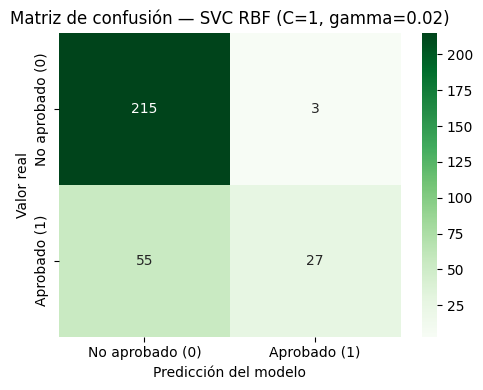

In [ ]:
# 21. Matriz de confusión del mejor SVC

matriz_confusion_svc = confusion_matrix(y_test, y_pred_svc)

plt.figure(figsize=(5, 4))
sns.heatmap(matriz_confusion_svc, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No aprobado (0)', 'Aprobado (1)'],
            yticklabels=['No aprobado (0)', 'Aprobado (1)'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title(f'Matriz de confusión — SVC RBF (C={busqueda.best_params_["C"]}, gamma={busqueda.best_params_["gamma"]})')
plt.tight_layout()
plt.show()


### Tabla comparativa de KPIs — Regresión Logística vs. SVM

Para decidir cuál modelo llevar a producción, se comparan ambos, sobre el mismo conjunto de prueba, en las métricas que ya se calcularon para cada uno: accuracy, precisión, recall (sensibilidad), especificidad y AUC. La especificidad no se había calculado todavía — se obtiene de la misma matriz de confusión de cada modelo (`TN / (TN + FP)`), es decir, qué tan bien identifica cada modelo a quienes *no* deben ser aprobados.

In [ ]:
# 22. Especificidad de cada modelo, a partir de su matriz de confusión

especificidad = matriz_confusion[0, 0] / (matriz_confusion[0, 0] + matriz_confusion[0, 1])
especificidad_svc = matriz_confusion_svc[0, 0] / (matriz_confusion_svc[0, 0] + matriz_confusion_svc[0, 1])

tabla_kpi = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Accuracy': exactitud,
        'Precisión': precision,
        'Recall (Sensibilidad)': sensibilidad,
        'Especificidad': especificidad,
        'AUC': auc,
    },
    {
        'Modelo': 'SVM (RBF)',
        'Accuracy': exactitud_svc,
        'Precisión': precision_svc,
        'Recall (Sensibilidad)': sensibilidad_svc,
        'Especificidad': especificidad_svc,
        'AUC': auc_svc,
    },
])
tabla_kpi


,Modelo,Accuracy,Precisión,Recall (Sensibilidad),Especificidad,AUC
0,Regresión Logística,0.817,0.729,0.524,0.927,0.869
1,SVM (RBF),0.807,0.900,0.329,0.986,0.865


### Gráfico comparativo de KPIs (conjunto de prueba)

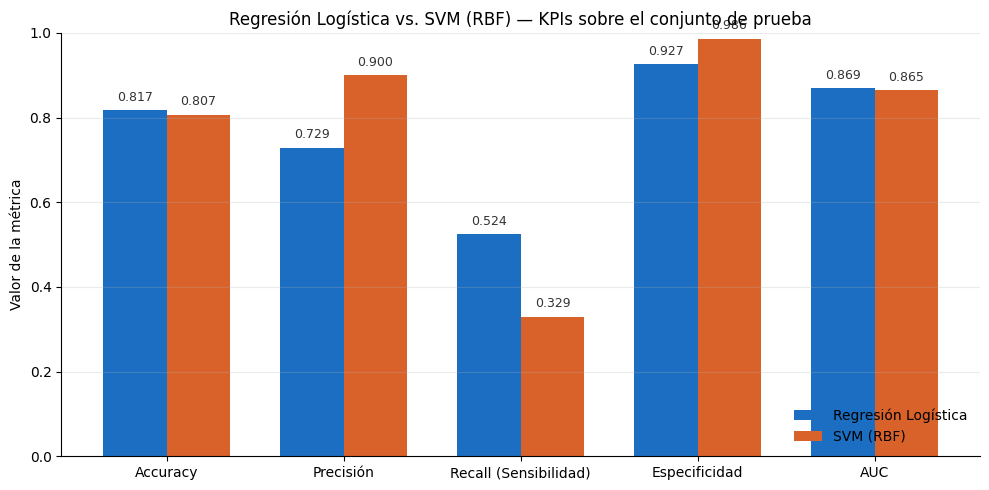

In [ ]:
# 23. Gráfico de barras comparando ambos modelos en las cinco métricas

metricas_nombres = ['Accuracy', 'Precisión', 'Recall (Sensibilidad)', 'Especificidad', 'AUC']
valores_lr = [exactitud, precision, sensibilidad, especificidad, auc]
valores_svm = [exactitud_svc, precision_svc, sensibilidad_svc, especificidad_svc, auc_svc]

color_lr = '#1B6EC2'
color_svm = '#D9622B'

x = np.arange(len(metricas_nombres))
ancho = 0.36

fig, ax = plt.subplots(figsize=(10, 5))
barras_lr = ax.bar(x - ancho/2, valores_lr, width=ancho, color=color_lr, label='Regresión Logística')
barras_svm = ax.bar(x + ancho/2, valores_svm, width=ancho, color=color_svm, label='SVM (RBF)')

for grupo in (barras_lr, barras_svm):
    for barra in grupo:
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width() / 2, altura + 0.015, f'{altura:.3f}',
                ha='center', va='bottom', fontsize=9, color='#333333')

ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres)
ax.set_ylim(0, 1.0)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Regresión Logística vs. SVM (RBF) — KPIs sobre el conjunto de prueba')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.25)
fig.tight_layout()
plt.show()


### Conclusión: ¿cuál elegir para un ambiente productivo?

El gráfico y la tabla comparativa muestran que ambos modelos presentan un desempeño similar, aunque con diferencias en sus métricas. El SVM con kernel RBF, configurado con C = 1 y gamma = 0.02, obtuvo una accuracy de 0.807, precisión de 0.900, recall de 0.329, especificidad de 0.986 y AUC de 0.865. La Regresión Logística obtuvo una accuracy de 0.817, precisión de 0.729, recall de 0.524, especificidad de 0.927 y AUC de 0.869.

Para un ambiente productivo de aprobación de crédito, se recomienda la **Regresión Logística**, principalmente porque presenta un mejor desempeño general en este conjunto de datos, especialmente en **recall y AUC**:

* Permite interpretar los coeficientes y explicar con mayor facilidad las decisiones del modelo. Esto es importante en un contexto donde las decisiones de aprobación deben ser comprensibles y justificables.

* Aunque el SVM presenta una mayor precisión y especificidad, también genera más falsos negativos, lo que se refleja en su menor recall. Por lo tanto, la Regresión Logística ofrece un mejor equilibrio entre desempeño, interpretabilidad y facilidad de implementación para este caso.

*En resumen:* con los resultados obtenidos utilizando *C = 1 y gamma = 0.02*, la Regresión Logística presenta un desempeño global ligeramente superior en este conjunto de prueba, principalmente por su mayor accuracy, recall y AUC, además de ofrecer una interpretación más directa de las variables.

El SVM con kernel RBF destaca por su alta precisión y especificidad, por lo que resulta especialmente efectivo para evitar falsos positivos, pero su menor recall implica que deja sin identificar una mayor cantidad de solicitudes aprobables. Por estas diferencias, la selección del modelo debe depender del costo que tenga para el negocio cada tipo de error y de la necesidad de interpretabilidad del modelo.